In [4]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("wildfire.csv")

In [6]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["occured"].value_counts())
df.head()

Shape: (118858, 17)

Class distribution:
occured
1.0    59452
0.0    59406
Name: count, dtype: int64


,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,occured,frp
0,0.0,-15.19928,38.54393,5.654271,955.608333,136.083333,43.611845,250.333333,15.883333,18.375000,4.89,35.0,23.175000,12.9,13.5,0.0,3.69
1,1.0,31.51203,-101.57546,16.564673,927.016667,181.333333,31.925260,296.916667,10.529167,3.416667,7.24,16.0,29.733333,13.4,16.2,0.0,0.73
2,1.0,-13.74538,28.05493,5.542089,884.379167,109.166667,8.379870,210.958333,6.095833,12.208333,3.68,35.0,14.104167,11.1,16.8,0.0,0.78
3,0.0,13.53091,-11.22573,7.703410,981.158333,168.416667,133.287570,244.208333,13.095833,56.458333,5.59,29.0,26.704167,12.9,11.0,0.0,8.91
4,0.0,5.61833,16.59892,16.895093,917.116667,202.208333,91.791875,266.750000,6.712500,9.166667,6.00,10.0,26.820833,16.0,16.6,0.0,5.97


In [7]:
df_model = df.drop(columns=["frp"])
df_model = df_model.dropna(subset=["occured"])

In [8]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=67,
    stratify=df_model["occured"]   # now safe — no NaN in label
)

print(f"\nTrain size: {len(train_df)} | Test size: {len(test_df)}")


Train size: 95086 | Test size: 23772


In [9]:
train_data = TabularDataset(train_df)
test_data = TabularDataset(test_df)

LABEL = "occured"

predictor = TabularPredictor(
    label=LABEL,
    problem_type="binary",          
    eval_metric="accuracy",        
    path="wildfire_model", 
).fit(
    train_data,
    presets="best_quality",
    time_limit=600,                 
    verbosity=2,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.5.0: Tue Apr 22 19:54:26 PDT 2025; root:xnu-11417.121.6~2/RELEASE_ARM64_T8112
CPU Count:          8
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.47 GB / 16.00 GB (15.4%)
Disk Space Avail:   51.14 GB / 460.43 GB (11.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether th

In [10]:
leaderboard = predictor.leaderboard(test_data, silent=False)
print("\nTop model:", leaderboard.iloc[0]["model"])

test_score = predictor.evaluate(test_data)
print("\nTest metrics:", test_score)

                      model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    NeuralNetFastAI_BAG_L2    0.669022   0.675105    accuracy        6.563364      12.675392  298.992282                 0.678296                0.540590          33.501825            2       True         21
1         LightGBMXT_BAG_L2    0.668391   0.674663    accuracy        5.994153      12.314756  268.887807                 0.109085                0.179954           3.397350            2       True         14
2           LightGBM_BAG_L2    0.668097   0.674726    accuracy        6.039005      12.426368  267.866571                 0.153937                0.291566           2.376115            2       True         15
3       WeightedEnsemble_L3    0.667845   0.676703    accuracy        8.537645      20.160684  372.537281                 0.001950                0.002850          

In [11]:
y_pred = predictor.predict(test_data.drop(columns=[LABEL]))
y_prob = predictor.predict_proba(test_data.drop(columns=[LABEL]))

print("\nSample predictions:")
print(pd.concat([
    test_data[[LABEL]].reset_index(drop=True),
    y_pred.rename("predicted").reset_index(drop=True),
    y_prob.reset_index(drop=True)
], axis=1).head(10))


Sample predictions:
   occured  predicted         0         1
0      0.0        1.0  0.496139  0.503861
1      0.0        0.0  0.667429  0.332571
2      1.0        1.0  0.379210  0.620790
3      1.0        0.0  0.528466  0.471534
4      0.0        1.0  0.426359  0.573641
5      0.0        1.0  0.403728  0.596272
6      1.0        1.0  0.203178  0.796822
7      0.0        1.0  0.411581  0.588419
8      0.0        0.0  0.906305  0.093695
9      1.0        0.0  0.555167  0.444833


Computing feature importance via permutation shuffling for 15 features using 5000 rows with 5 shuffle sets...
	302.47s	= Expected runtime (60.49s per shuffle set)
	109.33s	= Actual runtime (Completed 5 of 5 shuffle sets)



Feature Importance:
                          importance    stddev   p_value  n  p99_high  \
daynight_N                   0.08364  0.005679  0.000003  5  0.095333   
lon                          0.02384  0.007288  0.000929  5  0.038845   
lat                          0.02208  0.005873  0.000548  5  0.034173   
cloud_cover_mean             0.01076  0.002621  0.000391  5  0.016156   
solar_radiation_mean         0.01056  0.003401  0.001130  5  0.017563   
dewpoint_mean                0.00972  0.002356  0.000384  5  0.014572   
fire_weather_index           0.00940  0.003929  0.002944  5  0.017491   
temp_range                   0.00688  0.003065  0.003693  5  0.013190   
pressure_mean                0.00660  0.002429  0.001854  5  0.011601   
humidity_min                 0.00628  0.002252  0.001685  5  0.010917   
temp_mean                    0.00492  0.003936  0.024528  5  0.013024   
wind_speed_max               0.00440  0.002015  0.004072  5  0.008549   
wind_direction_std           0

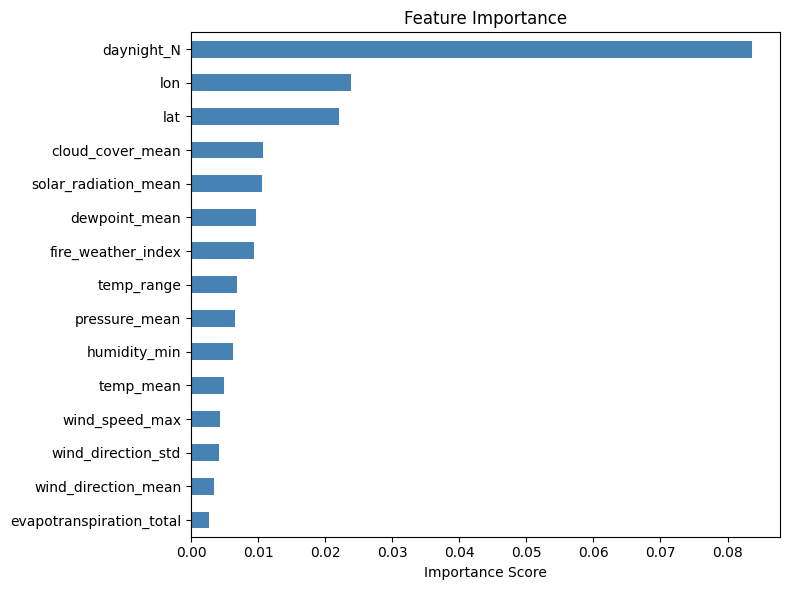

In [12]:
importance = predictor.feature_importance(test_data)
print("\nFeature Importance:")
print(importance)

importance["importance"].sort_values().plot(
    kind="barh", figsize=(8, 6), color="steelblue"
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

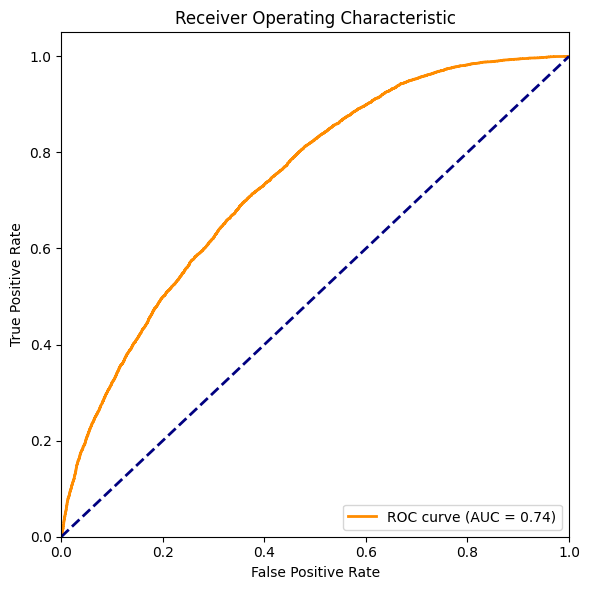

In [13]:
# roc curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(test_data[LABEL], y_prob[1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()